# Load and check dataset

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
print(df.head())

# Quick check
print(df.info())
print(df.describe())
print(df.isnull().sum())


   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80          75      

In [ ]:
# Install necessary libraries
!pip install pandas numpy scikit-learn matplotlib seaborn


# Imports

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans



# Data Preprocessing and Clustering Pipeline

Dropped columns due to missing values: Index(['Sleep Disorder'], dtype='object')
After dropping missing rows: (374, 13)


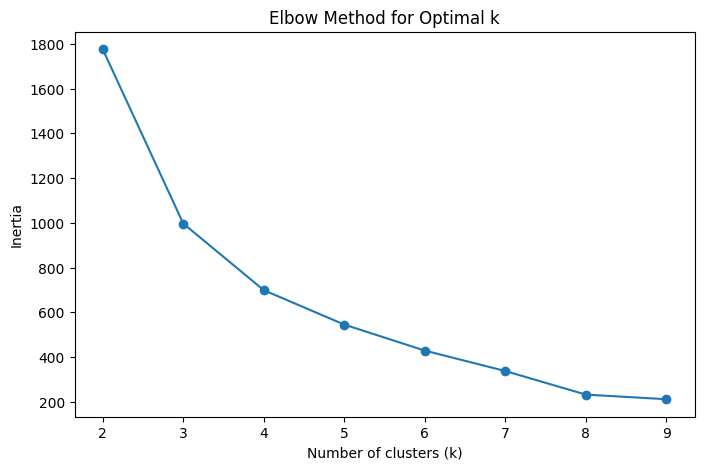

   Person ID  Sleep_Cluster
0          1              2
1          2              1
2          3              1
3          4              2
4          5              2
               Sleep Duration  Physical Activity Level  Stress Level  \
Sleep_Cluster                                                          
0                    7.617021                63.404255      4.242553   
1                    6.073529                88.235294      8.000000   
2                    6.389524                40.285714      7.095238   

               Heart Rate   Daily Steps  Sleep_Efficiency  
Sleep_Cluster                                              
0               67.948936   6954.042553          0.280408  
1               75.000000  10000.000000          0.108757  
2               73.561905   5479.047619          0.128787  


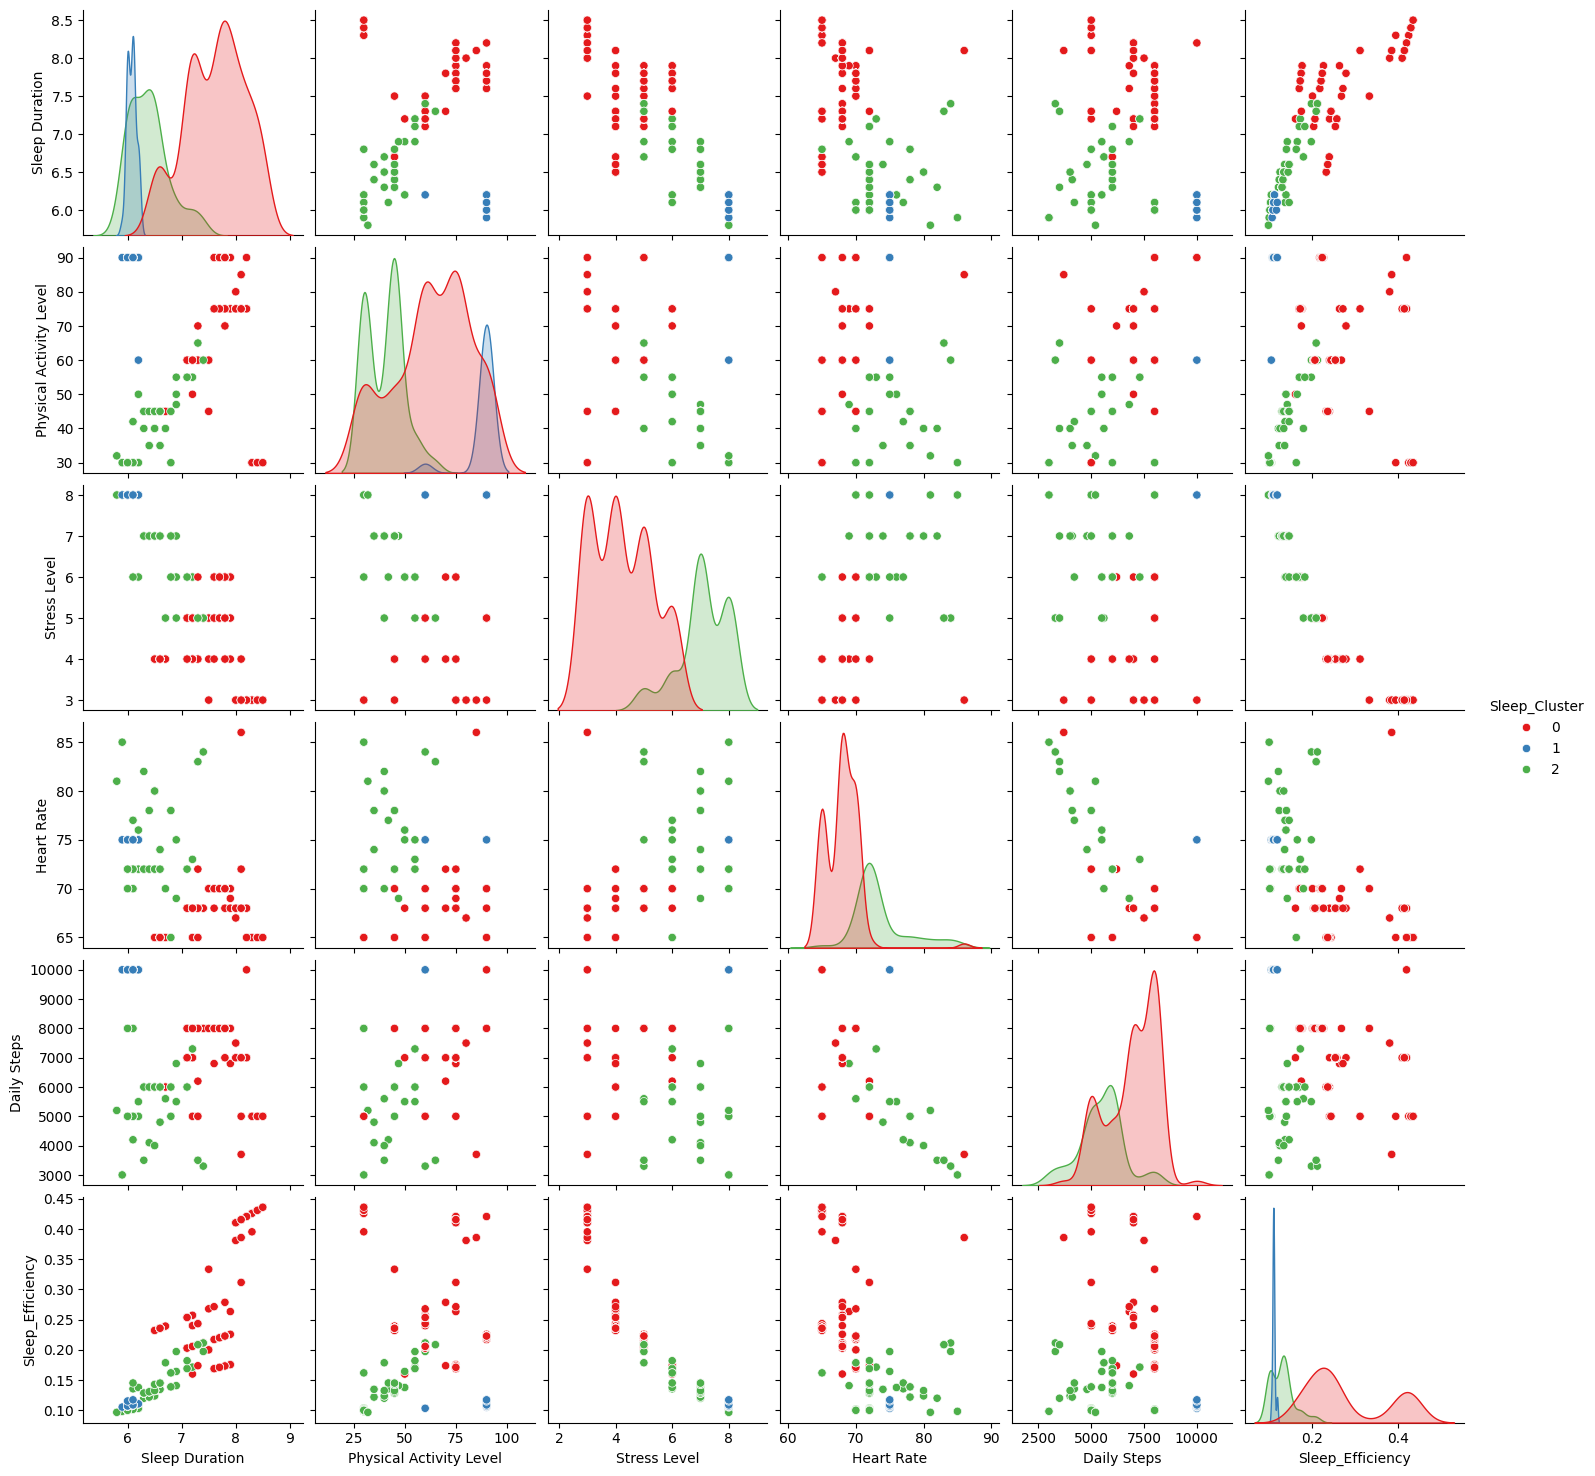

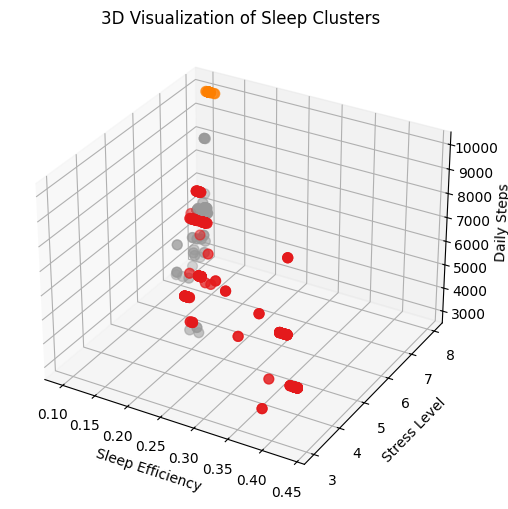

In [ ]:

# ---------------- Remove columns with excessive missing values ----------------

threshold = 0.3  # If more than 30% missing → drop column
cols_to_drop = df.columns[df.isnull().mean() > threshold]
df_cleaned = df.drop(columns=cols_to_drop)

print("Dropped columns due to missing values:", cols_to_drop)

# ----------------  Target Variable Handling (Binary Good/Poor Sleep) ----------------
df_cleaned['Quality_of_Sleep_Cat'] = df_cleaned['Quality of Sleep'].apply(
    lambda x: "Good" if x >= 7 else "Poor"
)

# ----------------  Remove remaining rows with missing values ----------------
df_cleaned = df_cleaned.dropna()
print("After dropping missing rows:", df_cleaned.shape)

# ---------------- Extra Feature: Sleep Efficiency Score ----------------
def age_factor(age):
    if age <= 35:
        return 7.5
    elif age <= 50:
        return 7.0
    else:
        return 6.5

df_cleaned['Age_Factor'] = df_cleaned['Age'].apply(age_factor)
df_cleaned['Sleep_Efficiency'] = df_cleaned['Sleep Duration'] / (df_cleaned['Stress Level'] * df_cleaned['Age_Factor'])

# ----------------  Prepare features for clustering ----------------
cluster_features = ['Sleep Duration', 'Physical Activity Level', 'Stress Level',
                    'Heart Rate', 'Daily Steps', 'Sleep_Efficiency']

# Scale features for clustering
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(df_cleaned[cluster_features])

# ----------------  Elbow method to find optimal k ----------------
inertia = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_cluster_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,10), inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

# ----------------  Fit K-Means ----------------
k = 3  # elbow method wise
kmeans = KMeans(n_clusters=k, random_state=42)
df_cleaned['Sleep_Cluster'] = kmeans.fit_predict(X_cluster_scaled)

print(df_cleaned[['Person ID', 'Sleep_Cluster']].head())

# ---------------- Analyze cluster characteristics ----------------
cluster_summary = df_cleaned.groupby('Sleep_Cluster')[cluster_features].mean()
print(cluster_summary)

# ---------------- Visualize clusters ----------------
sns.pairplot(df_cleaned, vars=cluster_features, hue='Sleep_Cluster', palette='Set1')
plt.show()

# 3D scatter for SES vs Stress vs Steps
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_cleaned['Sleep_Efficiency'], df_cleaned['Stress Level'], df_cleaned['Daily Steps'],
           c=df_cleaned['Sleep_Cluster'], cmap='Set1', s=50)
ax.set_xlabel('Sleep Efficiency')
ax.set_ylabel('Stress Level')
ax.set_zlabel('Daily Steps')
plt.title('3D Visualization of Sleep Clusters')
plt.show()


# ----------------  One-hot encode remaining categorical columns ----------------
categorical_cols = ['Gender', 'Occupation', 'BMI Category', 'Daily Steps', 'Blood Pressure']
df_cleaned = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

# 8.Add cluster as a feature
X = df_cleaned.drop(['Quality of Sleep', 'Quality_of_Sleep_Cat'], axis=1)
y = df_cleaned['Quality_of_Sleep_Cat']

# ----------------  Standardize numeric columns ----------------
numeric_cols = ['Age', 'Sleep Duration', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Sleep_Efficiency']

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# ----------------  Train-test split (STRATIFIED) ----------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Model Definition, Training, and Evaluation

In [ ]:
# Define models
models = {
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Logistic Regression': LogisticRegression(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier()
}

# Train and evaluate each model
results = {}
for model_name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Predict on test set
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = model.score(X_test, y_test)
    classification_rep = classification_report(y_test, y_pred)
    confusion_mat = confusion_matrix(y_test, y_pred)

    results[model_name] = {
        'Accuracy': accuracy,
        'Classification Report': classification_rep,
        'Confusion Matrix': confusion_mat
    }

    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:\n", classification_rep)
    print("Confusion Matrix:\n", confusion_mat)
    print("-" * 50)


Model: Naive Bayes
Accuracy: 0.9823
Classification Report:
               precision    recall  f1-score   support

        Good       1.00      0.97      0.99        78
        Poor       0.95      1.00      0.97        35

    accuracy                           0.98       113
   macro avg       0.97      0.99      0.98       113
weighted avg       0.98      0.98      0.98       113

Confusion Matrix:
 [[76  2]
 [ 0 35]]
--------------------------------------------------
Model: SVM
Accuracy: 0.6903
Classification Report:
               precision    recall  f1-score   support

        Good       0.69      1.00      0.82        78
        Poor       0.00      0.00      0.00        35

    accuracy                           0.69       113
   macro avg       0.35      0.50      0.41       113
weighted avg       0.48      0.69      0.56       113

Confusion Matrix:
 [[78  0]
 [35  0]]
--------------------------------------------------
Model: K-Nearest Neighbors
Accuracy: 0.9027
Classificati

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model: Random Forest
Accuracy: 1.0000
Classification Report:
               precision    recall  f1-score   support

        Good       1.00      1.00      1.00        78
        Poor       1.00      1.00      1.00        35

    accuracy                           1.00       113
   macro avg       1.00      1.00      1.00       113
weighted avg       1.00      1.00      1.00       113

Confusion Matrix:
 [[78  0]
 [ 0 35]]
--------------------------------------------------
Model: Logistic Regression
Accuracy: 1.0000
Classification Report:
               precision    recall  f1-score   support

        Good       1.00      1.00      1.00        78
        Poor       1.00      1.00      1.00        35

    accuracy                           1.00       113
   macro avg       1.00      1.00      1.00       113
weighted avg       1.00      1.00      1.00       113

Confusion Matrix:
 [[78  0]
 [ 0 35]]
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model: Gradient Boosting
Accuracy: 0.9912
Classification Report:
               precision    recall  f1-score   support

        Good       0.99      1.00      0.99        78
        Poor       1.00      0.97      0.99        35

    accuracy                           0.99       113
   macro avg       0.99      0.99      0.99       113
weighted avg       0.99      0.99      0.99       113

Confusion Matrix:
 [[78  0]
 [ 1 34]]
--------------------------------------------------
Model: AdaBoost
Accuracy: 1.0000
Classification Report:
               precision    recall  f1-score   support

        Good       1.00      1.00      1.00        78
        Poor       1.00      1.00      1.00        35

    accuracy                           1.00       113
   macro avg       1.00      1.00      1.00       113
weighted avg       1.00      1.00      1.00       113

Confusion Matrix:
 [[78  0]
 [ 0 35]]
--------------------------------------------------


# Visualizing the predictive performance of all trained models

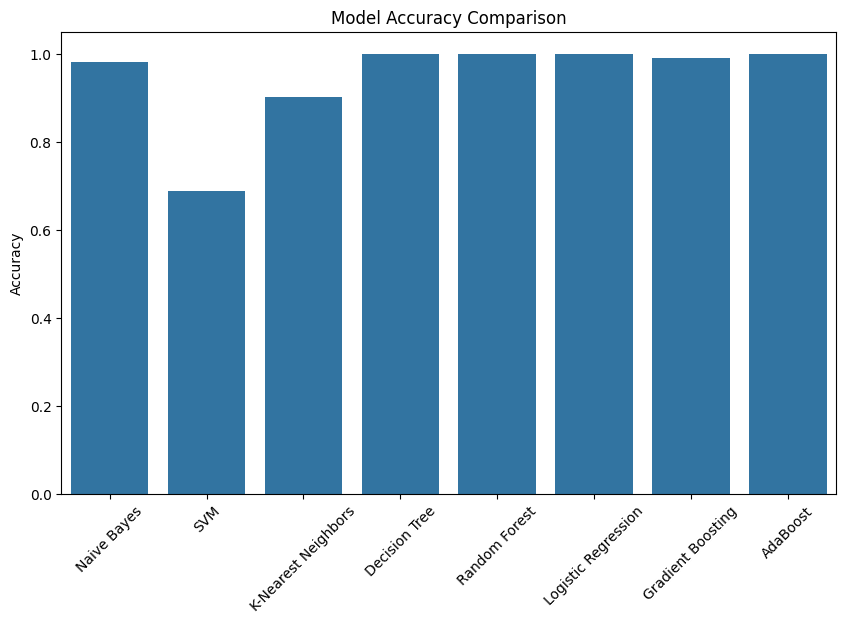

In [ ]:
# ----------------  Accuracy comparison plot ----------------
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x=list(results.keys()), y=[results[m]['Accuracy'] for m in results])
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

# Hyperparameter Tuning for Random Forest

In [ ]:

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)

print("Best RF params:", grid_rf.best_params_)
best_model = grid_rf.best_estimator_

# ---------------- Evaluate tuned Random Forest ----------------
y_pred_best = best_model.predict(X_test)
print("Tuned Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_best))

Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Tuned Random Forest Classification Report:

              precision    recall  f1-score   support

        Good       1.00      1.00      1.00        78
        Poor       1.00      1.00      1.00        35

    accuracy                           1.00       113
   macro avg       1.00      1.00      1.00       113
weighted avg       1.00      1.00      1.00       113



In [ ]:
!pip install shap


In [ ]:
import shap


# Convert all feature columns to numeric (float) type

In [ ]:

X_train_numeric = X_train.apply(lambda x: x.astype(float))
X_test_numeric = X_test.apply(lambda x: x.astype(float))

print(X_train_numeric.dtypes)  # should all be float64
print(X_test_numeric.dtypes)   # should all be float64


Person ID                  float64
Age                        float64
Sleep Duration             float64
Physical Activity Level    float64
Stress Level               float64
                            ...   
Blood Pressure_135/90      float64
Blood Pressure_139/91      float64
Blood Pressure_140/90      float64
Blood Pressure_140/95      float64
Blood Pressure_142/92      float64
Length: 66, dtype: object
Person ID                  float64
Age                        float64
Sleep Duration             float64
Physical Activity Level    float64
Stress Level               float64
                            ...   
Blood Pressure_135/90      float64
Blood Pressure_139/91      float64
Blood Pressure_140/90      float64
Blood Pressure_140/95      float64
Blood Pressure_142/92      float64
Length: 66, dtype: object


# SHAP (SHapley Additive exPlanations) Analysis for Model Interpretability

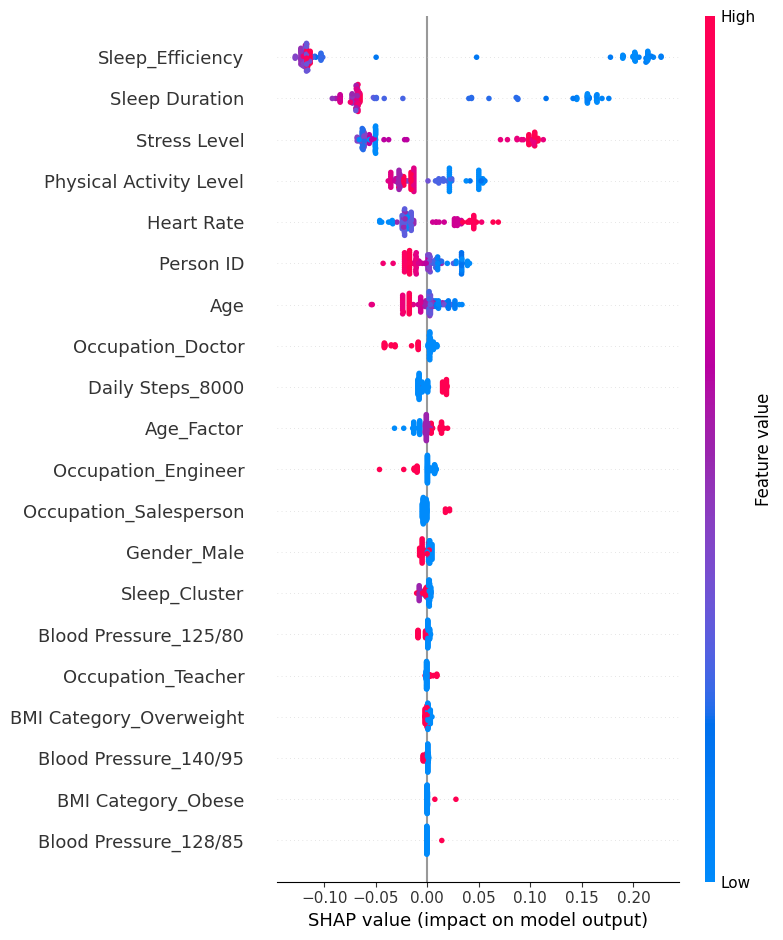

In [ ]:
import shap

# Make sure all features are float
X_train_numeric = X_train.astype(float)
X_test_numeric = X_test.astype(float)

# ----------------  SHAP Explainer ----------------
explainer = shap.Explainer(best_model, X_train_numeric)

# Compute SHAP values
shap_values = explainer(X_test_numeric)

# ----------------  Force plot for first sample, class 1 ----------------
shap.initjs()
shap.plots.force(
    shap_values.base_values[0,1],       # base value for first sample, class 1
    shap_values.values[0,:,1],          # SHAP values for first sample, class 1
    X_test_numeric.iloc[0],             # feature values
    feature_names=X_test_numeric.columns
)
shap.summary_plot(
    shap_values.values[:,:,1],  # all samples, all features, class 1
    X_test_numeric
)
